# **Large Language Models Lab(MCSE642P)**

# CNN for Image Classification
**SHRIHARIHARAN S (24MCS1058)**

**M.TECH CSE 1ST YEAR**




 ---------------------

*we have taken the Fashion_mnist dataset and developed the LeNet and various epochs and check the performance of the LeNet model*

In [1]:
pip install --upgrade tensorflow

In [2]:
#importing modules
from keras import backend as K
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Activation
from keras.layers import Flatten
from keras.layers import Dense
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.optimizers import SGD, RMSprop, Adam
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#define the ConvNet
class LeNet:
  @staticmethod
  def build(input_shape, classes):
    model = Sequential()
    # CONV => RELU => POOL
    model.add(Conv2D(20, kernel_size=5, padding="same",input_shape=input_shape))
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    # CONV => RELU => POOL
    model.add(Conv2D(50, kernel_size=5, padding="same"))
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    # Flatten => RELU layers
    model.add(Flatten())
    model.add(Dense(500))
    model.add(Activation("relu"))
    # a softmax classifier
    model.add(Dense(classes))
    model.add(Activation("softmax"))
    return model

In [4]:
# network and training
NB_EPOCH = 20
BATCH_SIZE = 128
VERBOSE = 1
OPTIMIZER = Adam()
VALIDATION_SPLIT=0.2
IMG_ROWS, IMG_COLS = 28, 28 # input image dimensions
NB_CLASSES = 10 # number of outputs = number of digits
INPUT_SHAPE = (1,IMG_ROWS, IMG_COLS)
# data: shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
K.set_image_data_format("channels_first")
# consider them as float and normalize
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255


In [5]:
# we need a 60K x [1 x 28 x 28] shape as input to the CONVNET
X_train = X_train[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

60000 train samples
10000 test samples


In [6]:
# convert class vectors to binary class matrices
y_train = to_categorical(y_train, NB_CLASSES)
y_test = to_categorical(y_test, NB_CLASSES)

In [7]:
# initialize the optimizer and model
model = LeNet.build(input_shape=INPUT_SHAPE, classes=NB_CLASSES)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(loss="categorical_crossentropy", optimizer=OPTIMIZER,metrics=["accuracy"])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 20, 28, 28)          │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 20, 28, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 14, 14)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 50, 14, 14)          │          25,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 50, 14, 14)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 50, 7, 7)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2450)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 500)                 │       1,225,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,256,080 (4.79 MB)

 Trainable params: 1,256,080 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=NB_EPOCH, validation_split=VALIDATION_SPLIT)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7446 - loss: 0.7063 - val_accuracy: 0.8723 - val_loss: 0.3534
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8823 - loss: 0.3306 - val_accuracy: 0.8874 - val_loss: 0.3072
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8961 - loss: 0.2815 - val_accuracy: 0.9019 - val_loss: 0.2773
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9147 - loss: 0.2354 - val_accuracy: 0.8895 - val_loss: 0.2968
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9243 - loss: 0.2071 - val_accuracy: 0.9120 - val_loss: 0.2438
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9333 - loss: 0.1867 - val_accuracy: 0.9112 - val_loss: 0.2410
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9409 - loss: 0.1625 - val_accuracy: 0.9183 - val_loss: 0.2358
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9473 - loss: 0.1452 - val_accuracy: 0

In [11]:
score = model.evaluate(X_test, y_test, verbose=VERBOSE)
print("Test loss:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9057 - loss: 0.4635
Test loss: 0.4565020501613617
Test accuracy: 0.9082000255584717


In [12]:
# list all data in history
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


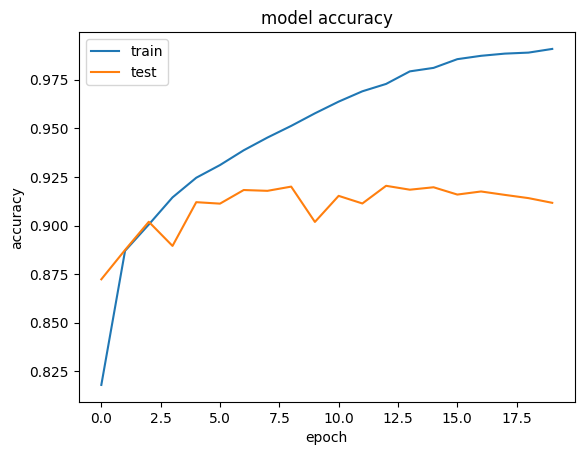

In [13]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

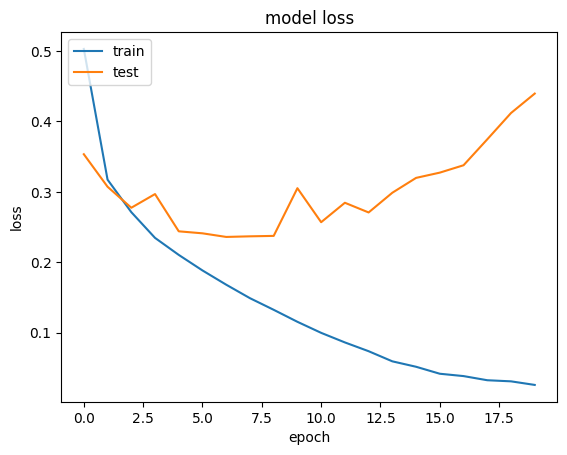

In [14]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# Step 1: Load and preprocess the data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the data to the range [0, 1] and reshape for CNN input
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)  # Shape for LeNet (28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Step 2: Define the model function for KerasClassifier
def create_lenet_model(learning_rate=0.001, dropout_rate=0.5):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),  # Input layer explicitly
        layers.Conv2D(6, kernel_size=(5, 5), activation='relu', padding='same'),
        layers.AvgPool2D(pool_size=(2, 2), padding='same'),  # Add padding='same' to AveragePooling2D
        layers.Conv2D(16, kernel_size=(5, 5), activation='relu', padding='same'),
        layers.AvgPool2D(pool_size=(2, 2), padding='same'),  # Add padding='same' to AveragePooling2D
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Step 3: Define different hyperparameters to loop through
epochs_list = [10, 20]  # Different numbers of epochs to try
learning_rate_list = [0.001, 0.0001]
dropout_rate_list = [0.3, 0.5]

best_accuracy = 0
best_params = {}

# Step 4: Loop through different combinations of epochs and other hyperparameters
for epochs in epochs_list:
    for learning_rate in learning_rate_list:
        for dropout_rate in dropout_rate_list:
            print(f"Training model with epochs={epochs}, learning_rate={learning_rate}, dropout_rate={dropout_rate}")

            model = create_lenet_model(learning_rate=learning_rate, dropout_rate=dropout_rate)

            # Train the model with current hyperparameters
            model.fit(x_train, y_train, epochs=epochs, batch_size=64, verbose=0)

            # Evaluate the model on the test data
            test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

            # Print the test accuracy for the current combination
            print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

            # Update the best accuracy and corresponding parameters
            if test_accuracy > best_accuracy:
                best_accuracy = test_accuracy
                best_params = {'epochs': epochs, 'learning_rate': learning_rate, 'dropout_rate': dropout_rate}

# Step 5: Print the best hyperparameters and accuracy
print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Test Accuracy: {best_accuracy * 100:.2f}%")


Training model with epochs=10, learning_rate=0.001, dropout_rate=0.3
Test Accuracy: 87.29%
Training model with epochs=10, learning_rate=0.001, dropout_rate=0.5
Test Accuracy: 86.64%
Training model with epochs=10, learning_rate=0.0001, dropout_rate=0.3
Test Accuracy: 80.83%
Training model with epochs=10, learning_rate=0.0001, dropout_rate=0.5
Test Accuracy: 80.66%
Training model with epochs=20, learning_rate=0.001, dropout_rate=0.3
Test Accuracy: 88.24%
Training model with epochs=20, learning_rate=0.001, dropout_rate=0.5
Test Accuracy: 88.19%
Training model with epochs=20, learning_rate=0.0001, dropout_rate=0.3
Test Accuracy: 83.53%
Training model with epochs=20, learning_rate=0.0001, dropout_rate=0.5
Test Accuracy: 83.25%

Best Hyperparameters: {'epochs': 20, 'learning_rate': 0.001, 'dropout_rate': 0.3}
Best Test Accuracy: 88.24%


**Inference:**


*   The Lenet Model achieved the overall the Test accuracy of 90.82000255584717%
*   We used For loop based Hyperparameter tuning to find the best combination of epochs,Learning Rate and Drop out rate to achieve the Maximum Test accuracy


*   We have achieved the Best Hyperparameters:

{'epochs': 20, 'learning_rate': 0.001, 'dropout_rate': 0.3}

Best Test Accuracy: 88.24%
*   We can further fine tune by including multiple hyperparameters



